<a href="https://colab.research.google.com/github/LeonimerMelo/Recurrent-Networks/blob/Time-Series-Analysis/Time_Series_Analysis_v6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a class="anchor" id="0"></a>
#Time Series Analysis in Python

A time series is a series of data points recorded at different time-intervals. The time series analysis means analyzing the time series data using various statistical tools and techniques.

Séries temporais são, fundamentalmente, qualquer série de pontos de dados indexados ou listados ou grafados em uma ordem sucessiva. Geralmente, uma série temporal é uma sequência tomada em pontos de tempo consecutivos. Esses pontos de dados podem ser observados em intervalos consistentes, como a cada segundo, minuto, hora, dia, mês, ano, etc.

Uma forma fácil de visualizar uma série temporal é pensar numa linha do tempo, onde os eventos ou valores são registrados conforme acontecem. Por exemplo, pode-se registrar a temperatura de uma cidade a cada hora. Nesse caso, a linha do tempo mostra as variações horárias da temperatura.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib as mpl
import matplotlib.pyplot as plt   # data visualization
import seaborn as sns             # statistical data visualization

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


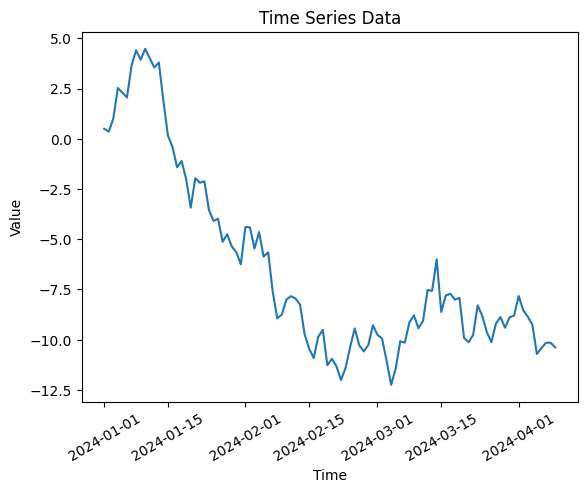

In [ ]:
# Generate random time-series data
np.random.seed(42) # maintain seed for same data
dates = pd.date_range(start='2024-01-01', periods=100, freq='D')
values = np.random.randn(100).cumsum()

# Create a DataFrame from the generated data
data = pd.DataFrame({'date': dates, 'value': values})

# Set the 'date' column as the index
data.set_index('date', inplace=True)

# Plot the time-series data
plt.plot(data.index, data['value'])
plt.xlabel('Time')
plt.ylabel('Value')
plt.xticks(rotation = 30)
plt.title('Time Series Data')
plt.show()


In this example, a random time-series dataset is generated using NumPy's random number generator. The dataset consists of 100 dates, starting from January 1, 2024, and corresponding random values. The data is then converted into a Pandas DataFrame, and the 'date' column is set as the index. Finally, the time-series data is plotted using Matplotlib, displaying the variation of the 'value' over time.

##Time Series Forecasting
Time series forecasting is exactly what it sounds like; predicting unknown values. Time series forecasting involves the collection of historical data, preparing it for algorithms to consume, and then predicting the future values based on patterns learned from the historical data.

There are numerous reasons why companies may be interested in forecasting future values, namely GDP (PIB em português), monthly sales, inventory, unemployment, and global temperatures:

- A retailer may be interested in predicting future sales at an SKU (stock keeping unit) level for planning and budgeting.
- A small merchant may be interested in forecasting sales by store, so it can schedule the right resources (more people during busy periods and vice versa).
- A software giant like Google may be interested in knowing the busiest hour of the day or busiest day of the week so that they can schedule server resources accordingly.
- The health department may be interested in predicting the cumulative COVID vaccinations administered so that they can further predict when herd immunity is expected to kick in.

##Conceitos Básicos de Séries Temporais
**Tendência (Trend)**: a direção para onde a série temporal está indo ao longo do tempo, podendo ser crescente, decrescente ou estável.

**Sazonalidade (seasonality)**: padrões cíclicos e repetitivos na série temporal, como vendas sazonais e variações de consumo de energia.

**Média Móvel (moving average)**: a média de uma série temporal em uma janela específica de tempo, utilizada para suavizar a série e identificar tendências e padrões.

**Resíduo (Residual)**: Refere-se às flutuações ou variações aleatórias na série que não são capturadas pela tendência ou sazonalidade.

##Introduction to Time-Series Analysis
- A **time-series** data is a series of data points or observations recorded at different or regular time intervals. In general, a time series is a sequence of data points taken at equally spaced time intervals.  The frequency of recorded data points may be hourly, daily, weekly, monthly, quarterly or annually.
- **Time-Series Forecasting** is the process of using a statistical model to predict future values of a time-series based on past results.
- A time series analysis encompasses statistical methods for analyzing time series data. These methods enable us to extract meaningful statistics, patterns and other characteristics of the data. Time series are visualized with the help of line charts. So, time series analysis involves understanding inherent aspects of the time series data so that we can create meaningful and accurate forecasts.
- Applications of time series are used in statistics, finance or business applications. A very common example of time series data is the daily closing value of the stock index like NASDAQ or Dow Jones. Other common applications of time series are sales and demand forecasting, weather forecasting, econometrics, signal processing, pattern recognition and earthquake prediction.

## Components of a Time-Series
- **Trend** - The trend shows a general direction of the time series data over a long period of time. A trend can be increasing(upward), decreasing(downward), or horizontal(stationary).
- **Seasonality** - The seasonality component exhibits a trend that repeats with respect to timing, direction, and magnitude. Some examples include an increase in water consumption in summer due to hot weather conditions.
- **Cyclical Component** - These are the trends with no set repetition over a particular period of time. A cycle refers to the period of ups and downs, booms and slums of a time series, mostly observed in business cycles. These cycles do not exhibit a seasonal variation but generally occur over a time period of 3 to 12 years depending on the nature of the time series.
- **Irregular Variation** - These are the fluctuations in the time series data which become evident when trend and cyclical variations are removed. These variations are unpredictable, erratic, and may or may not be random.
- **ETS Decomposition** - ETS Decomposition is used to separate different components of a time series. The term ETS stands for Error, Trend and Seasonality.

##Types of data
As stated above, the time series analysis is the statistical analysis of the time series data. A time series data means that data is recorded at different time periods or intervals. The time series data may be of three types:
1. **Time series data** - The observations of the values of a variable recorded at different points in time is called time series data.
2. **Cross sectional data** - It is the data of one or more variables recorded at the same point in time.
3. **Pooled data**- It is the combination of time series data and cross sectional data.


## Time Series terminology
There are various terms and concepts in time series that we should know. These are as follows:
1.	**Dependence**- It refers to the association of two observations of the same variable at prior time periods.
2.	**Stationarity**- It shows the mean value of the series that remains constant over the time period. If past effects accumulate and the values increase towards infinity then stationarity is not met.
3.	**Differencing**- Differencing is used to make the series stationary and to control the auto-correlations. There may be some cases in time series analyses where we do not require differencing and over-differenced series can produce wrong estimates.
4.	**Specification** - It may involve the testing of the linear or non-linear relationships of dependent variables by using time series models such as ARIMA models.
5.	**Exponential Smoothing** - Exponential smoothing in time series analysis predicts the one next period value based on the past and current value.  It involves averaging of data such that the non-systematic components of each individual case or observation cancel out each other.  The exponential smoothing method is used to predict the short term prediction.
6.	**Curve fitting** - Curve fitting regression in time series analysis is used when data is in a non-linear relationship.
7.	**ARIMA** - ARIMA stands for Auto Regressive Integrated Moving Average.


##Time Series Analysis


In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/Datasets/AirPassengers.csv'
df = pd.read_csv(path)
df.columns = ['Date','Number of Passengers']
df.head(10)

,Date,Number of Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
5,1949-06,135
6,1949-07,148
7,1949-08,148
8,1949-09,136
9,1949-10,119


In [ ]:
df.count()

Date                    144
Number of Passengers    144
dtype: int64

##Visualize the Time Series

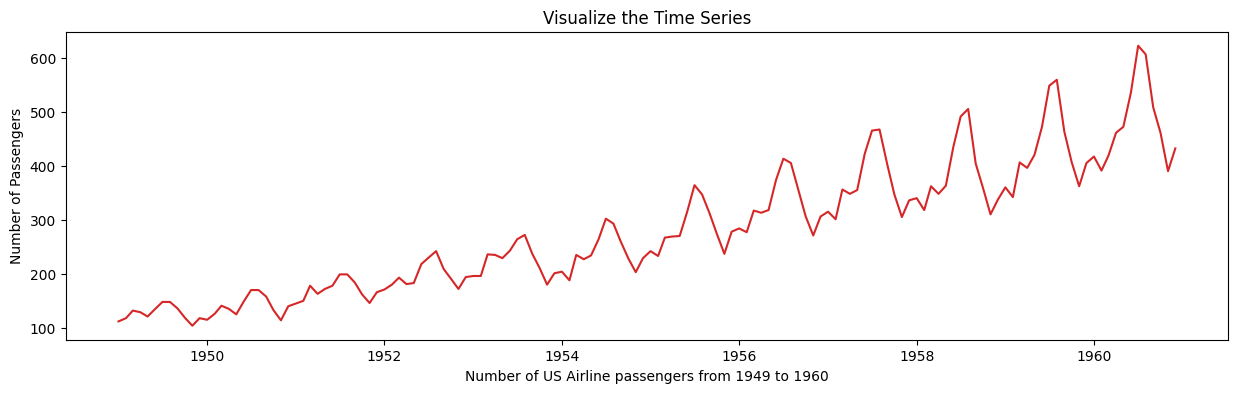

In [ ]:
x=df['Date']
y=df['Number of Passengers']
xlabel='Number of US Airline passengers from 1949 to 1960'
ylabel='Number of Passengers'
title="Visualize the Time Series"
plt.figure(figsize=(15,4), dpi=100)
x = np.asarray(x, dtype='datetime64[s]')
plt.plot(x, y, color='tab:red')
#plt.xticks(rotation = 30)
plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
plt.show()

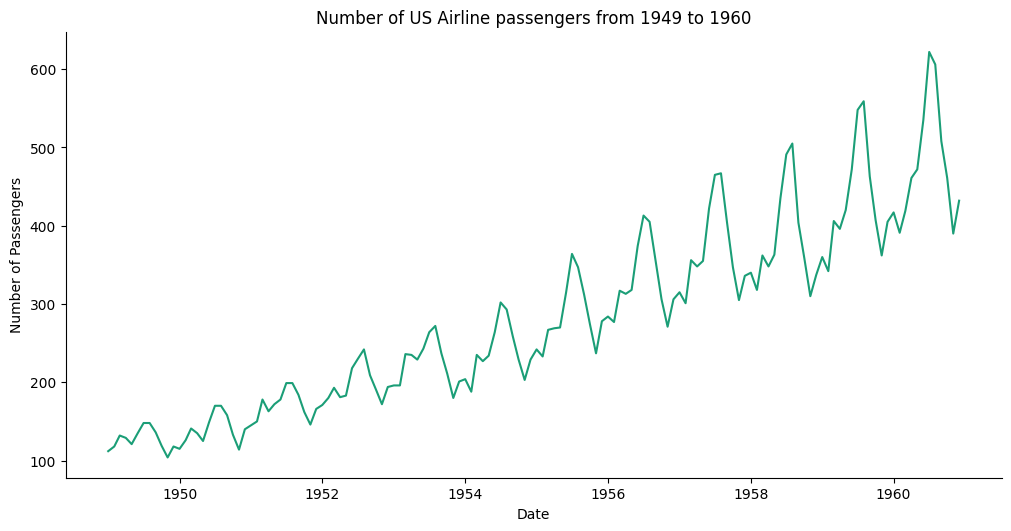

In [ ]:
# @title Date vs Number of Passengers
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Date']
  ys = series['Number of Passengers']
  xs = np.asarray(xs, dtype='datetime64[s]')
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('Date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Date')
plt.title('Number of US Airline passengers from 1949 to 1960')
_ = plt.ylabel('Number of Passengers')

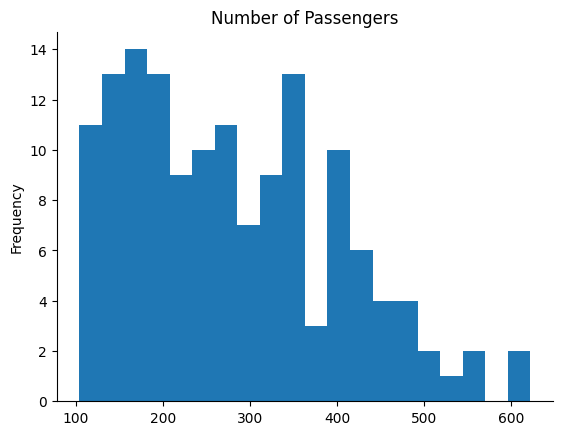

In [ ]:
# @title Number of Passengers
df['Number of Passengers'].plot(kind='hist', bins=20, title='Number of Passengers')
plt.gca().spines[['top', 'right',]].set_visible(False)

- Since all the values are positive, we can show this on both sides of the Y axis to emphasize the growth.

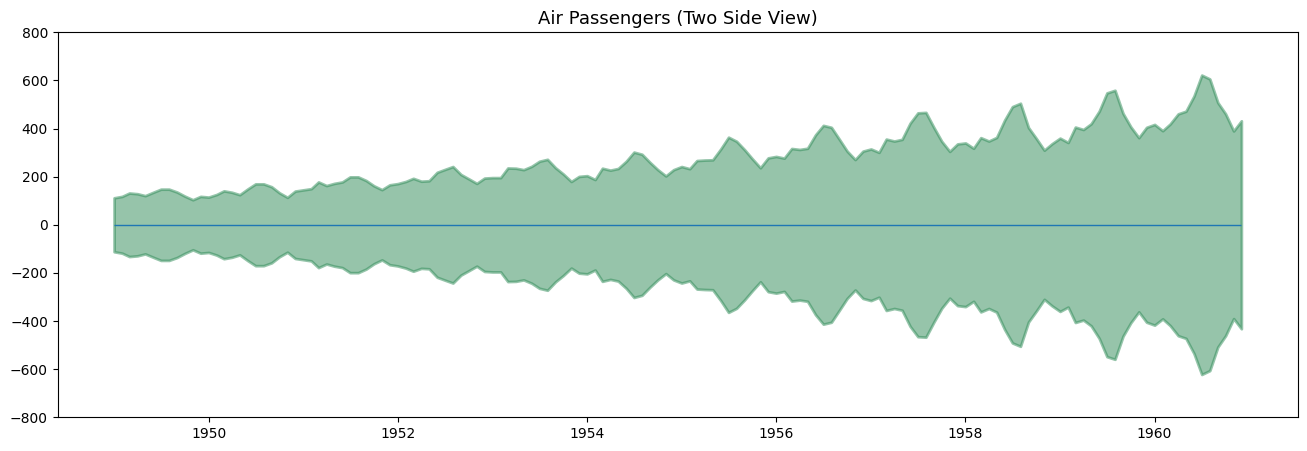

In [ ]:
x = df['Date'].values
y1 = df['Number of Passengers'].values
xs = np.asarray(x, dtype='datetime64[s]')

# Plot
fig, ax = plt.subplots(1, 1, figsize=(16,5), dpi= 100)
plt.fill_between(xs, y1=y1, y2=-y1, alpha=0.5, linewidth=2, color='seagreen')
plt.ylim(-800, 800)
plt.title('Air Passengers (Two Side View)', fontsize=13)
#plt.hlines(y=0, xmin=np.min(df['Date']), xmax=np.max(df['Date']), linewidth=.5)
plt.hlines(y=0, xmin=np.min(xs), xmax=np.max(xs), linewidth=1)
plt.show()

- It can be seen that its a monthly time series and follows a certain repetitive pattern every year. So, we can plot each year as a separate line in the same plot. This let us compare the year wise patterns side-by-side.

##Patterns in a Time Series
- Any time series visualization may consist of the following components: **Base Level + Trend + Seasonality + Error**.

### **Trend**
- A **trend** is observed when there is an increasing or decreasing slope observed in the time series.

### **Seasonality**
- A **seasonality** is observed when there is a distinct repeated pattern observed between regular intervals due to seasonal factors. It could be because of the month of the year, the day of the month, weekdays or even time of the day.

However, It is not mandatory that all time series must have a trend and/or seasonality. A time series may not have a distinct trend but have a seasonality and vice-versa.


### **Cyclic behaviour**

- Another important thing to consider is the **cyclic behaviour**. It happens when the rise and fall pattern in the series does not happen in fixed calendar-based intervals. We should not confuse 'cyclic' effect with 'seasonal' effect.

- If the patterns are not of fixed calendar based frequencies, then it is cyclic. Because, unlike the seasonality, cyclic effects are typically influenced by the business and other socio-economic factors.

##Additive and Multiplicative Time Series
We may have different combinations of trends and seasonality. Depending on the nature of the trends and seasonality, a time series can be modeled as an additive or multiplicative time series. Each observation in the series can be expressed as either a sum or a product of the components.

**Additive time series:**

Value = Base Level + Trend + Seasonality + Error

**Multiplicative Time Series:**

Value = Base Level x Trend x Seasonality x Error

##Decomposition of a Time Series

- Decomposition of a time series can be performed by considering the series as an additive or multiplicative combination of the base level, trend, seasonal index and the residual term.
- The seasonal_decompose in statsmodels implements this conveniently.

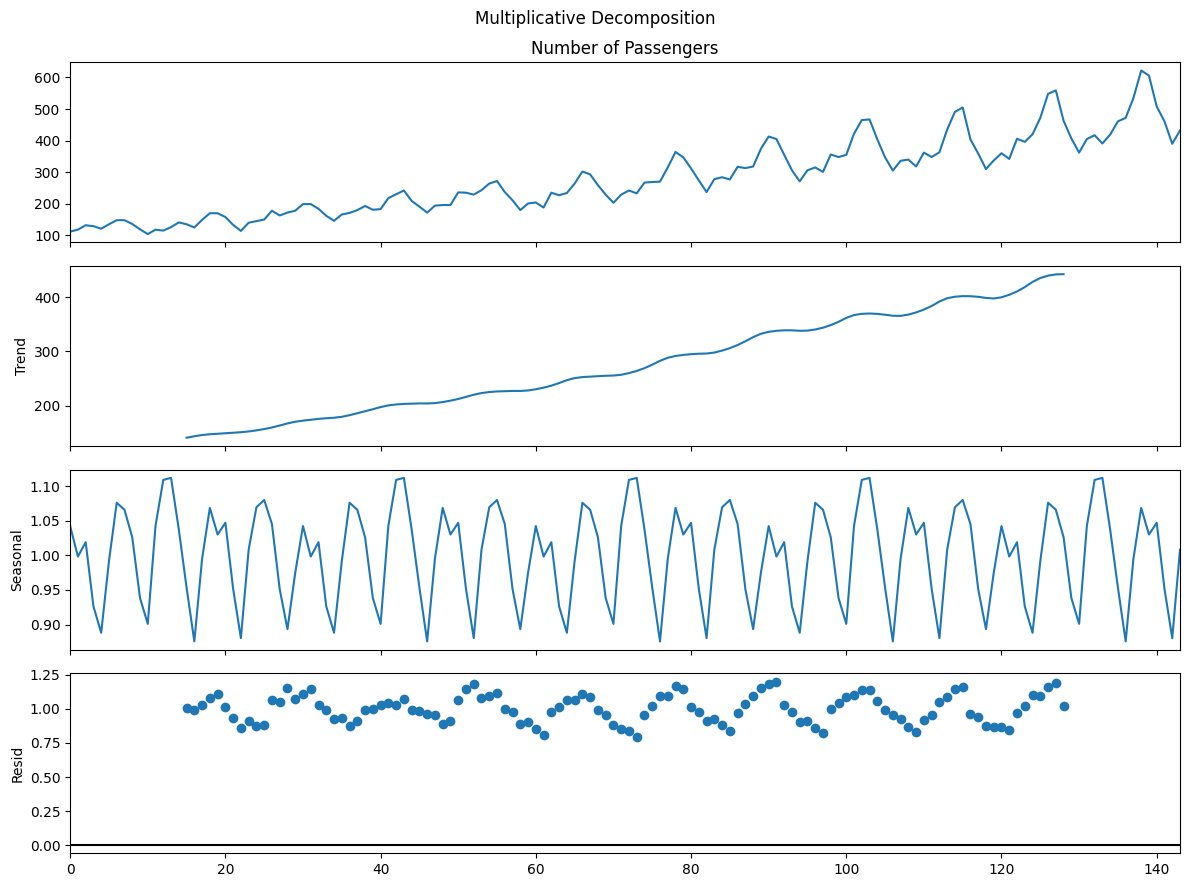

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse

# Multiplicative Decomposition
multiplicative_decomposition = seasonal_decompose(df['Number of Passengers'], model='multiplicative', period=30)

# Additive Decomposition
additive_decomposition = seasonal_decompose(df['Number of Passengers'], model='additive', period=30)

# Plot
plt.rcParams.update({'figure.figsize': (12,9)})
multiplicative_decomposition.plot().suptitle('Multiplicative Decomposition', fontsize=12)
plt.tight_layout()
plt.show()

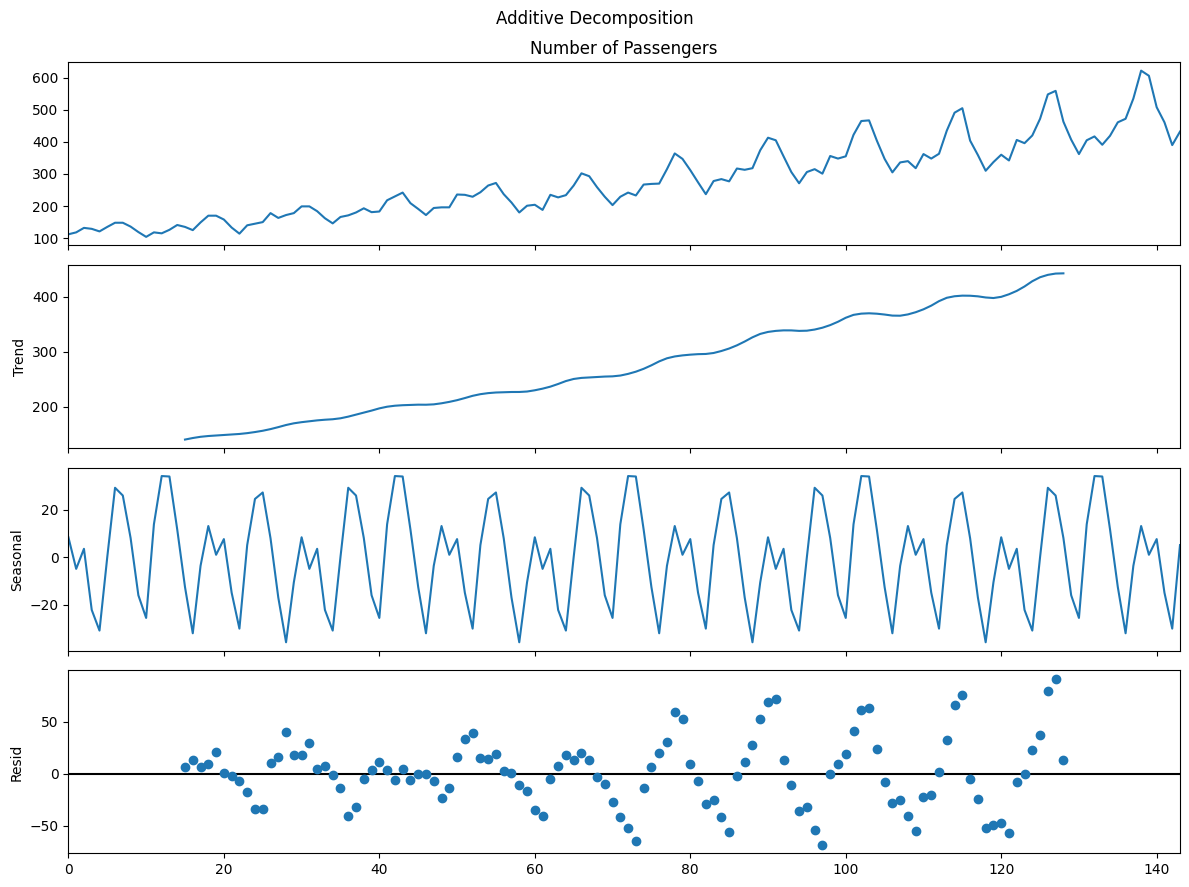

In [ ]:
additive_decomposition.plot().suptitle('Additive Decomposition', fontsize=12)
plt.tight_layout()
plt.show()

- If we look at the residuals of the additive decomposition closely, it has some pattern left over.

- The multiplicative decomposition, looks quite random which is good. So ideally, multiplicative decomposition should be preferred for this particular series.

##Séries Temporais Estacionárias
De maneira simplificada, ser estacionária significa ter a média, variância e covariância permanecendo constante ao longo da dimensão temporal, ou como o próprio nome diz ela seria estacionária.

Exemplos visuais de séries **não estacionárias**:

<center><img src='https://miro.medium.com/v2/resize:fit:640/format:webp/1*ZZx20yZAROPTnewIYZHVrQ.png' width=700></center>

Podemos reparar que no primeiro gráfico há uma tendência de alta, ou seja, a média está aumentando com o passar do tempo, no segundo gráfico a variância não seria constante e interfere na amplitude e no terceiro gráfico temos um exemplo de covariância que vária no decorrer do tempo.

Exemplo de série **estacionária**. Repare que ela é estacionária ou seja constante.

<center><img src='https://miro.medium.com/v2/resize:fit:310/format:webp/1*q3nzlSEx7yRaiiLzfaZBQg.png' width=200></center>

##Stationary and Non-Stationary Time Series

Now, we wil discuss **Stationary and Non-Stationary Time Series**. **Stationarity** is a property of a time series. A stationary series is one where the values of the series is not a function of time. So, the values are independent of time.

Hence the statistical properties of the series like mean, variance and autocorrelation are constant over time. Autocorrelation of the series is nothing but the correlation of the series with its previous values.

A stationary time series is independent of seasonal effects as well.

Now, we will plot some examples of stationary and non-stationary time series for clarity. Only the first one plot is stationary time serie.

![Stationary and Non-Stationary Time Series](https://www.machinelearningplus.com/wp-content/uploads/2019/02/stationary-and-non-stationary-time-series-865x569.png?ezimgfmt=ng:webp/ngcb1)

We can covert any non-stationary time series into a stationary one by applying a suitable transformation. Mostly statistical forecasting methods are designed to work on a stationary time series. The first step in the forecasting process is typically to do some transformation to convert a non-stationary series to stationary.

##Difference between white noise and a stationary series

Like a stationary series, the white noise is also not a function of time. So, its mean and variance does not change over time. But the difference is that, the white noise is completely random with a mean of 0. In white noise there is no pattern.

Mathematically, a sequence of completely random numbers with mean zero is a white noise.

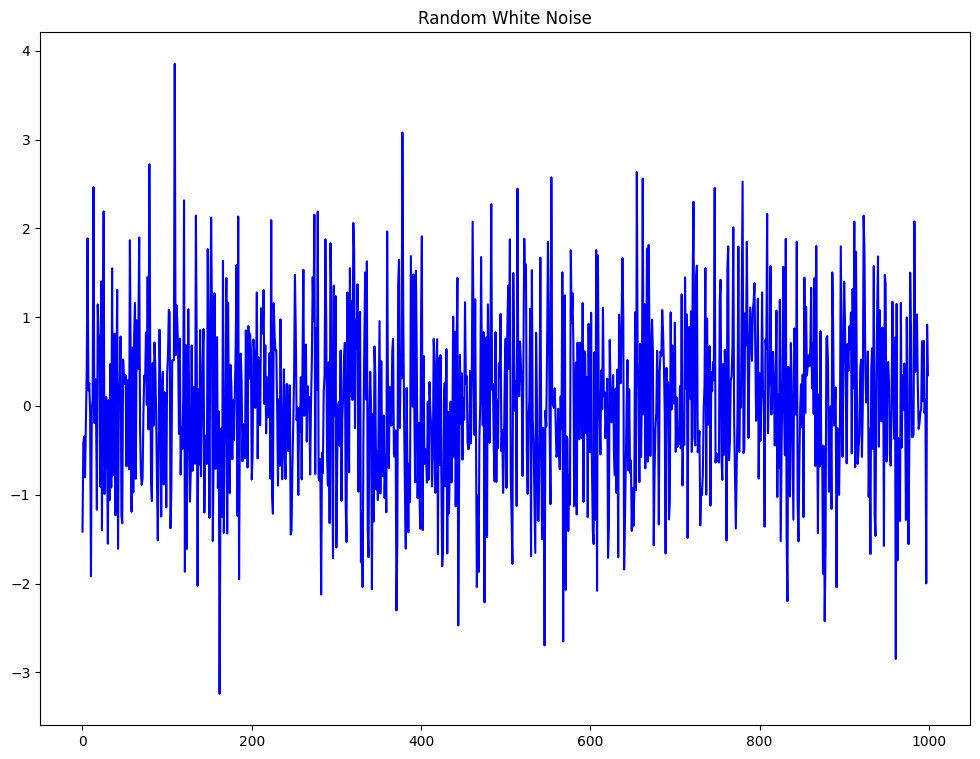

In [ ]:
rand_numbers = np.random.randn(1000)
pd.Series(rand_numbers).plot(title='Random White Noise', color='b')
plt.show()

##Detrend a Time Series
Detrending a time series means to remove the trend component from the time series. There are multiple approaches of doing this as listed below:

1. Subtract the line of best fit from the time series. The line of best fit may be obtained from a linear regression model with the time steps as the predictor. For more complex trends, we may want to use quadratic terms (x^2) in the model.
2. We subtract the trend component obtained from time series decomposition.
3. Subtract the mean.
4. Apply a filter like Baxter-King filter(statsmodels.tsa.filters.bkfilter) or the Hodrick-Prescott Filter (statsmodels.tsa.filters.hpfilter) to remove the moving average trend lines or the cyclical components.

Now, we will implement the first two methods to detrend a time series.

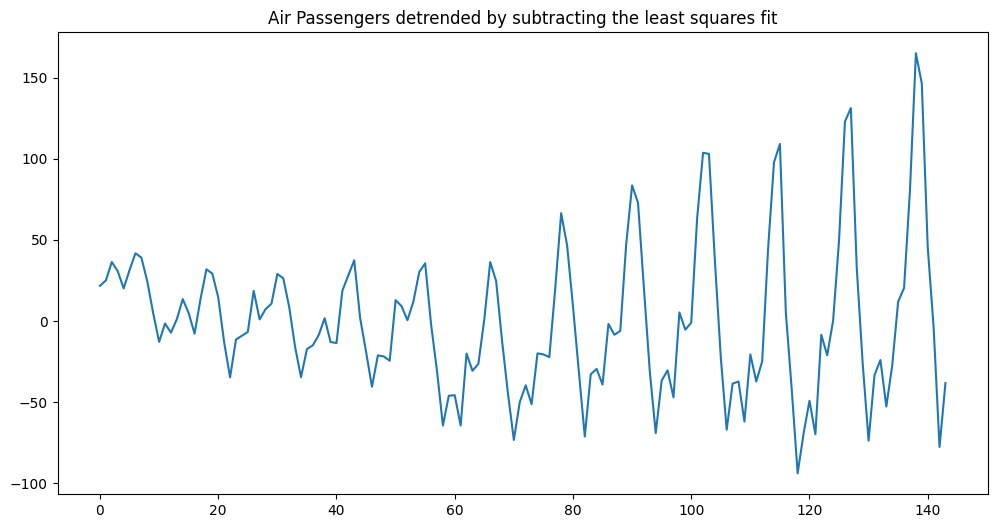

In [ ]:
# Using scipy: Subtract the line of best fit
from scipy import signal
detrended = signal.detrend(df['Number of Passengers'].values)
plt.figure(figsize=(12,6), dpi=100)
plt.plot(detrended)
plt.title('Air Passengers detrended by subtracting the least squares fit', fontsize=12)
plt.show()

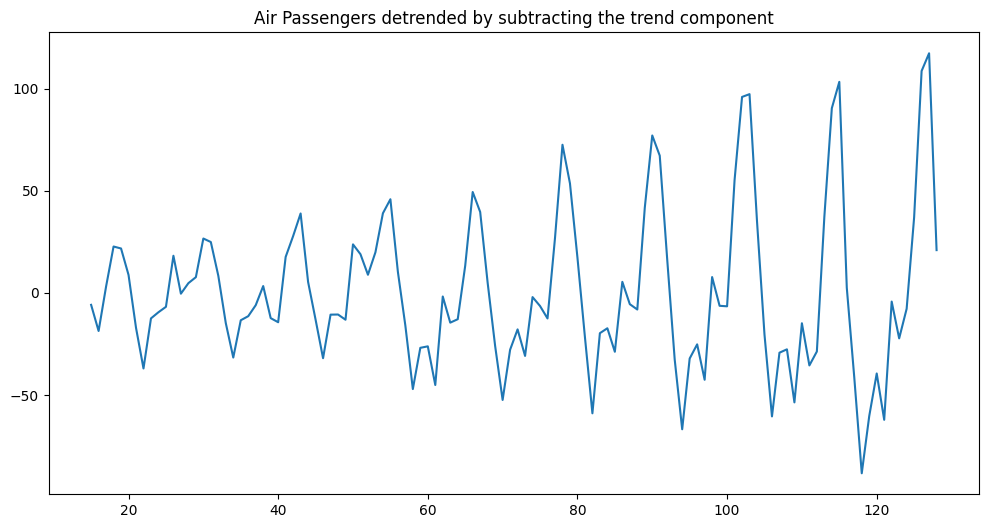

In [ ]:
# Using statmodels: Subtracting the Trend Component
from statsmodels.tsa.seasonal import seasonal_decompose
result_mul = seasonal_decompose(df['Number of Passengers'], model='multiplicative', period=30)
detrended = df['Number of Passengers'].values - result_mul.trend
plt.figure(figsize=(12,6), dpi=100)
plt.plot(detrended)
plt.title('Air Passengers detrended by subtracting the trend component', fontsize=12)
plt.show()

##Deseasonalize a Time Series
There are multiple approaches to deseasonalize a time series. These approaches are listed below:

1. Take a moving average with length as the seasonal window. This will smoothen in series in the process.
2. Seasonal difference the series (subtract the value of previous season from the current value).
3. Divide the series by the seasonal index obtained from STL decomposition.

If dividing by the seasonal index does not work well, we will take a log of the series and then do the deseasonalizing. We will later restore to the original scale by taking an exponential.


[]

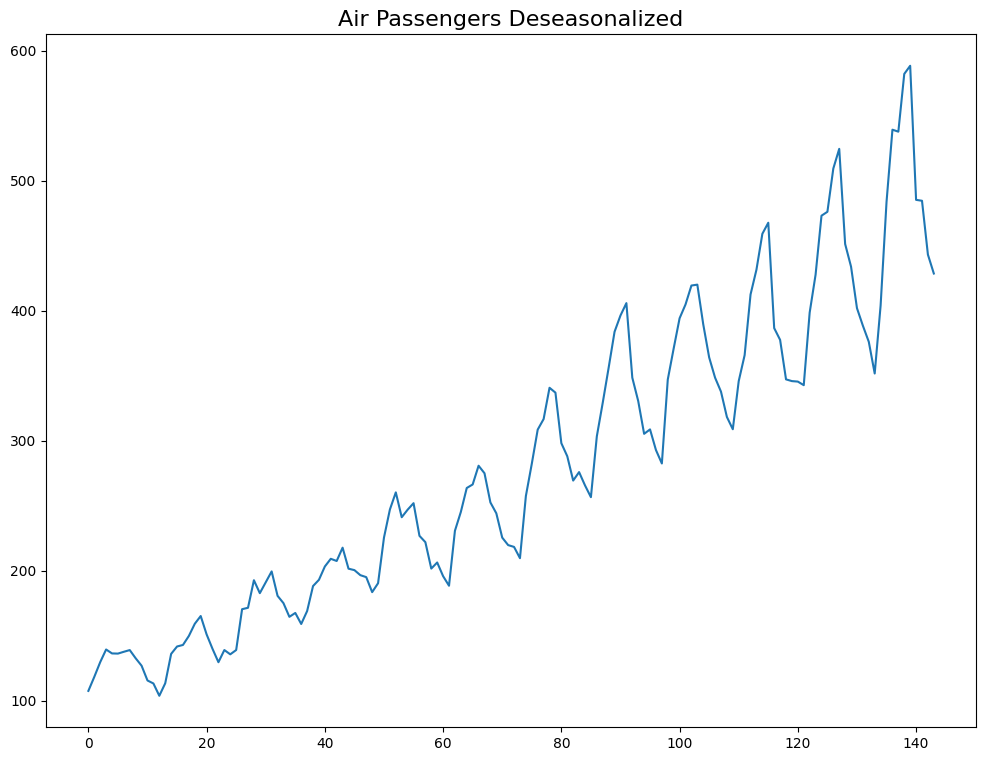

In [ ]:
# Subtracting the Trend Component
# Time Series Decomposition
result_mul = seasonal_decompose(df['Number of Passengers'], model='multiplicative', period=30)

# Deseasonalize
deseasonalized = df['Number of Passengers'].values / result_mul.seasonal

# Plot
plt.plot(deseasonalized)
plt.title('Air Passengers Deseasonalized', fontsize=16)
plt.plot()

##How to test for seasonality of a time series?
The common way to test for seasonality of a time series is to plot the series and check for repeatable patterns in fixed time intervals. So, the types of seasonality is determined by the clock or the calendar.
1. Hour of day
2. Day of month
3. Weekly
4. Monthly
5. Yearly

However, if we want a more definitive inspection of the seasonality, use the **Autocorrelation Function (ACF) plot**. There is a strong seasonal pattern, the ACF plot usually reveals definitive repeated spikes at the multiples of the seasonal window.

Autocorrelation analysis is an important step in the Exploratory Data Analysis (EDA) of time series. The autocorrelation analysis helps in detecting hidden patterns and seasonality and in checking for randomness.

**Autocorrelation Function (ACF)**. Correlation between time series with a lagged version of itself. The correlation between the observation at the current time spot and the observations at previous time spots.The autocorrelation function starts a lag 0, which is the correlation of the time series with itself and therefore results in a correlation of 1.

A time series is a sequence of measurements of the same variable(s) made over time. Usually, the measurements are made at evenly spaced times — for example, monthly or yearly. The coefficient of correlation between two values in a time series is called the autocorrelation function (ACF). In other words,

- Autocorrelation represents the degree of similarity between a given time series and a lagged version of itself over successive time intervals.
- Autocorrelation measures the relationship between a variable’s current value and its past values.
- An autocorrelation of +1 represents a perfect positive correlation, while an autocorrelation of -1 represents a perfect negative correlation.

**Why useful?**
- Help us uncover hidden patterns in our data and help us select the correct forecasting methods.
- Help identify seasonality in our time series data.
- Analyzing the autocorrelation function (ACF) and partial autocorrelation function (PACF) in conjunction is necessary for selecting the appropriate ARIMA model for any time series prediction.

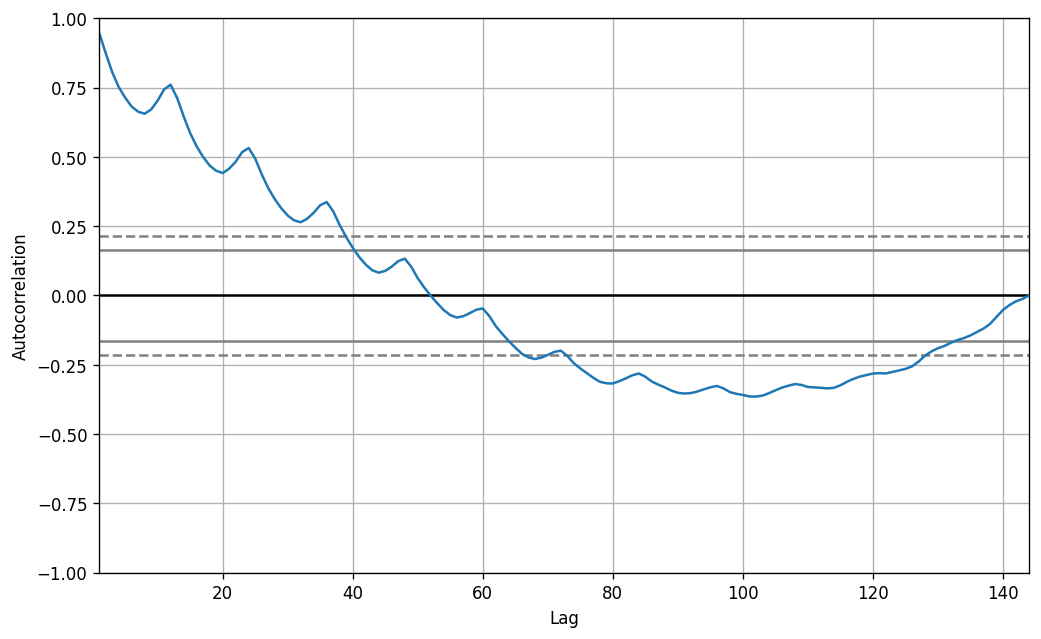

In [ ]:
# Test for seasonality
from pandas.plotting import autocorrelation_plot

# Draw Plot
plt.rcParams.update({'figure.figsize':(10,6), 'figure.dpi':120})
autocorrelation_plot(df['Number of Passengers'].tolist())
plt.show()

Alternately, if we want a statistical test, the [CHTest](https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.CHTest.html#pmdarima.arima.CHTest) can determine if seasonal differencing is required to stationarize the series.

##What Is Autocorrelation?
Autocorrelation is a mathematical representation of the degree of similarity between a given time series and a lagged version of itself over successive time intervals. It's conceptually similar to the correlation between two different time series, but autocorrelation uses the same time series twice: once in its original form and once lagged one or more time periods.

For example, if it's rainy today, the data suggests that it's more likely to rain tomorrow than if it's clear today. When it comes to investing, a stock might have a strong positive autocorrelation of returns, suggesting that if it's "up" today, it's more likely to be up tomorrow, too.

Naturally, autocorrelation can be a useful tool for traders to utilize; particularly for technical analysts.

When calculating autocorrelation, the result can range from -1 to +1.

An autocorrelation of +1 represents a perfect positive correlation: an increase seen in one time series leads to a proportionate increase in the other time series.

<center><img src='https://www.investopedia.com/thmb/f1D5NwKzCGUhKC6cEW1Ep9JEldU=/750x0/filters:no_upscale():max_bytes(150000):strip_icc():format(webp)/1Auto-336e0893344f4ef3abd033cc83ddd93e.PNG' width=500></center>

On the other hand, an autocorrelation of -1 represents a perfect negative correlation: an increase seen in one time series results in a proportionate decrease in the other time series.

<center><img src='https://www.investopedia.com/thmb/a3LogFit3TrCTWK4HRGqQwMB2Ss=/750x0/filters:no_upscale():max_bytes(150000):strip_icc():format(webp)/-1auto-96995b5335fa41a3ac51981667d04eb7.PNG' width=500></center>

Autocorrelation measures linear relationships. Even if the autocorrelation is minuscule, there can still be a nonlinear relationship between a time series and a lagged version of itself.

##Autocorrelation and Partial Autocorrelation Functions
- **Autocorrelation** is simply the correlation of a series with its own lags. If a series is significantly autocorrelated, that means, the previous values of the series (lags) may be helpful in predicting the current value.
- **Partial Autocorrelation** also conveys similar information but it conveys the pure correlation of a series and its lag, excluding the correlation contributions from the intermediate lags.

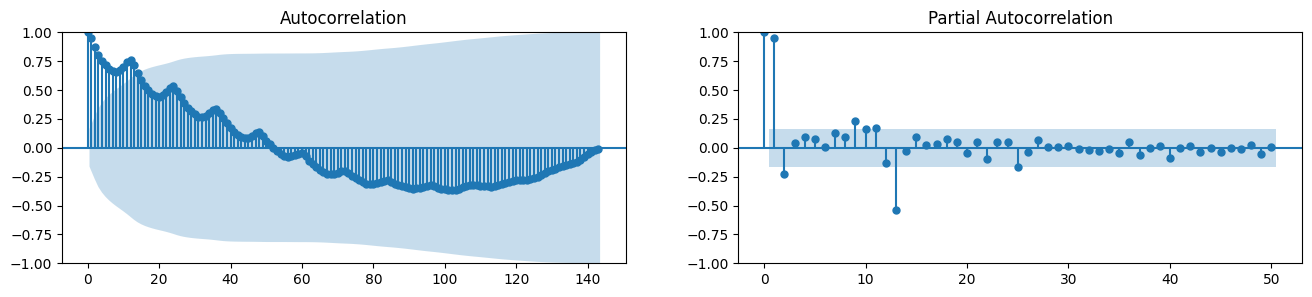

In [ ]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Draw Plot
fig, axes = plt.subplots(1,2,figsize=(16,3), dpi= 100)
plot_acf(df['Number of Passengers'].tolist(), lags=143, ax=axes[0])
plot_pacf(df['Number of Passengers'].tolist(), lags=50, ax=axes[1])
plt.show()

##Computation of Partial Autocorrelation Function
- The partial autocorrelation function of lag (k) of a series is the coefficient of that lag in the autoregression equation of Y. The autoregressive equation of Y is nothing but the linear regression of Y with its own lags as predictors.
- For example, if $Y_t$ is the current series and $Y_t-1$ is the lag 1 of $Y$, then the partial autocorrelation of $lag 3 (Y_{t-3})$ is the coefficient $\alpha_3$ of $Y_{t-3}$ in the following equation:

$$Y_t=\alpha_0 + \alpha_1 Y_{t-1} + \alpha_2 Y_{t-2} + \alpha_3 Y_{t-3}$$

##Lag Plots
A **Lag plot** is a scatter plot of a time series against a lag of itself. It is normally used to check for autocorrelation. If there is any pattern existing in the series, the series is autocorrelated. If there is no such pattern, the series is likely to be random white noise.


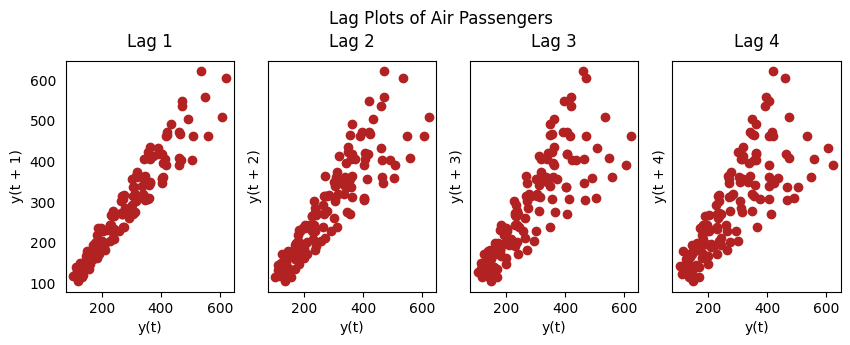

In [ ]:
from pandas.plotting import lag_plot
plt.rcParams.update({'ytick.left' : False, 'axes.titlepad':10})

# Plot
fig, axes = plt.subplots(1, 4, figsize=(10,3), sharex=True, sharey=True, dpi=100)
for i, ax in enumerate(axes.flatten()[:4]):
    lag_plot(df['Number of Passengers'], lag=i+1, ax=ax, c='firebrick')
    ax.set_title('Lag ' + str(i+1))

fig.suptitle('Lag Plots of Air Passengers', y=1.05)
plt.show()

##Granger Causality Test
**Granger causality test** is used to determine if one time **series will be useful to forecast another**. It is based on the idea that if X causes Y, then the forecast of Y based on previous values of Y AND the previous values of X should outperform the forecast of Y based on previous values of Y alone.

So, **Granger causality test** should not be used to test if a lag of Y causes Y. Instead, it is generally used on exogenous (not Y lag) variables only. It is implemented in the statsmodel package.

It accepts a 2D array with 2 columns as the main argument. The values are in the first column and the predictor (X) is in the second column. The Null hypothesis is that the series in the second column, does not Granger cause the series in the first. If the P-Values are less than a significance level (0.05) then we reject the null hypothesis and conclude that the said lag of X is indeed useful. The second argument maxlag says till how many lags of Y should be included in the test.

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests
# dataset AirPassengers
datas = df
datas['date'] = pd.to_datetime(datas['Date'])
datas['month'] = datas.date.dt.month
grangercausalitytests(datas[['Number of Passengers', 'month']], maxlag=2)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=7.4080  , p=0.0073  , df_denom=140, df_num=1
ssr based chi2 test:   chi2=7.5667  , p=0.0059  , df=1
likelihood ratio test: chi2=7.3733  , p=0.0066  , df=1
parameter F test:         F=7.4080  , p=0.0073  , df_denom=140, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=4.9761  , p=0.0082  , df_denom=137, df_num=2
ssr based chi2 test:   chi2=10.3154 , p=0.0058  , df=2
likelihood ratio test: chi2=9.9579  , p=0.0069  , df=2
parameter F test:         F=4.9761  , p=0.0082  , df_denom=137, df_num=2


{1: ({'ssr_ftest': (7.407967762077273, 0.007318844731632552, 140.0, 1),
   'ssr_chi2test': (7.566709928407499, 0.00594562186503604, 1),
   'lrtest': (7.373310381387228, 0.00661989587473731, 1),
   'params_ftest': (7.407967762077268, 0.007318844731632552, 140.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (4.976083922906452, 0.00819979590267562, 137.0, 2),
   'ssr_chi2test': (10.315385650404616, 0.0057549620839173355, 2),
   'lrtest': (9.95792312585968, 0.006881204546489823, 2),
   'params_ftest': (4.976083922906381, 0.008199795902676155, 137.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])])}

In [ ]:
# another dataset exemple
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/dataset.txt')
data.head()

,date,value
0,1991-07-01,3.526591
1,1991-08-01,3.180891
2,1991-09-01,3.252221
3,1991-10-01,3.611003
4,1991-11-01,3.565869


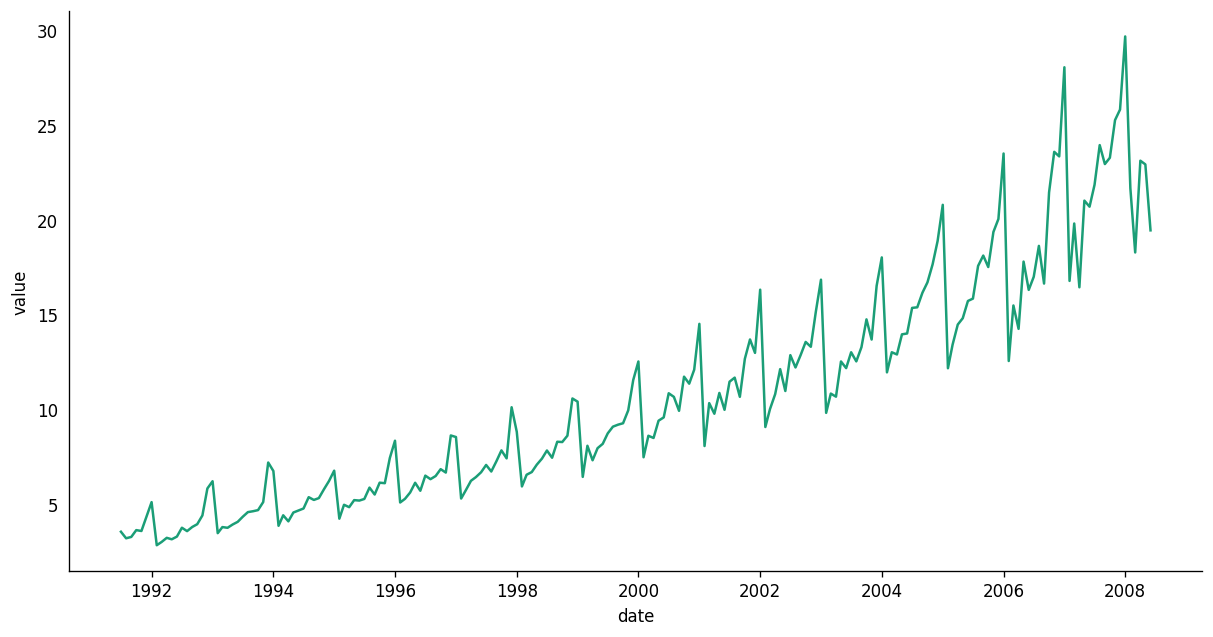

In [ ]:
# @title date vs value

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['date']
  xs = np.asarray(xs, dtype='datetime64[s]')
  ys = series['value']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = data.sort_values('date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('date')
_ = plt.ylabel('value')

In [ ]:
data['date'] = pd.to_datetime(data['date'])
data['month'] = data.date.dt.month
grangercausalitytests(data[['value', 'month']], maxlag=2)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=54.7797 , p=0.0000  , df_denom=200, df_num=1
ssr based chi2 test:   chi2=55.6014 , p=0.0000  , df=1
likelihood ratio test: chi2=49.1426 , p=0.0000  , df=1
parameter F test:         F=54.7797 , p=0.0000  , df_denom=200, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=162.6989, p=0.0000  , df_denom=197, df_num=2
ssr based chi2 test:   chi2=333.6567, p=0.0000  , df=2
likelihood ratio test: chi2=196.9956, p=0.0000  , df=2
parameter F test:         F=162.6989, p=0.0000  , df_denom=197, df_num=2


{1: ({'ssr_ftest': (54.7796748355736, 3.661425871353102e-12, 200.0, 1),
   'ssr_chi2test': (55.601369958107206, 8.876175235021478e-14, 1),
   'lrtest': (49.14260233004984, 2.38014300604565e-12, 1),
   'params_ftest': (54.77967483557365, 3.661425871352998e-12, 200.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (162.69891799873236, 1.9133235086857257e-42, 197.0, 2),
   'ssr_chi2test': (333.65666432227346, 3.5267600881280646e-73, 2),
   'lrtest': (196.99559277182198, 1.6709003499115789e-43, 2),
   'params_ftest': (162.69891799873244, 1.9133235086856426e-42, 197.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])])}

In the above case, the p-values are zero for all tests. So the ‘month’ indeed can be used to forecast the values.

##Exercícios
1. Faça uma análise no dataset do consumo de energia elétrica ao longo dos anos que pode ser utilizado diretamente do site abaixo:
dataset_path = "https://raw.githubusercontent.com/carlosfab/datasets/master/electricity_consumption/Electric_Production.csv". O formato da data neste banco de dados é string('MM-DD-YYYY').
1. Analise graficamente e comente a Tendência, Média Móvel, Sazonalidade e Resíduo da série temporal.
1. A séria apresenta características estacionárias ou não estacionárias?
1. Faça uma análise gráfica e quantitativa para se eliminar a tendência da série temporal. Comente os resultados.
1. Faça uma análise gráfica e quantitativa para dessazonalizar a série temporal. Comente os resultados.
1. A série apresenta autocorrelação? Pode-se fazer predições futuras nesta série com segurança?
1. Analise o gráfico da cotação do dolar comercial desde 07/1994 apresenada abaixo. Verifique a Tendência, Média Móvel e Sazonalidade da série. Verifique e analise a possibilidade de previsões futuras.

In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/Datasets/cot_dolar_s071994.csv'
usd = pd.read_csv(path)
usd.head()
# a data está em formato string 'd/m/Y'

,date,value
0,01/07/1994,0.900
1,04/07/1994,0.935
2,05/07/1994,0.927
3,06/07/1994,0.910
4,07/07/1994,0.905


In [ ]:
# converter a data para o format padrão
usd['ConvertedDate']=pd.to_datetime(usd['date'].astype(str), format='%d/%m/%Y')
usd.head()

,date,value,ConvertedDate
0,01/07/1994,0.900,1994-07-01
1,04/07/1994,0.935,1994-07-04
2,05/07/1994,0.927,1994-07-05
3,06/07/1994,0.910,1994-07-06
4,07/07/1994,0.905,1994-07-07


In [ ]:
# apagando a coluna duplicada
del usd['date']
usd.head()

,value,ConvertedDate
0,0.900,1994-07-01
1,0.935,1994-07-04
2,0.927,1994-07-05
3,0.910,1994-07-06
4,0.905,1994-07-07


In [ ]:
# reposicionando as colunas
usd = usd[['ConvertedDate','value']]
usd.head()

,ConvertedDate,value
0,1994-07-01,0.900
1,1994-07-04,0.935
2,1994-07-05,0.927
3,1994-07-06,0.910
4,1994-07-07,0.905


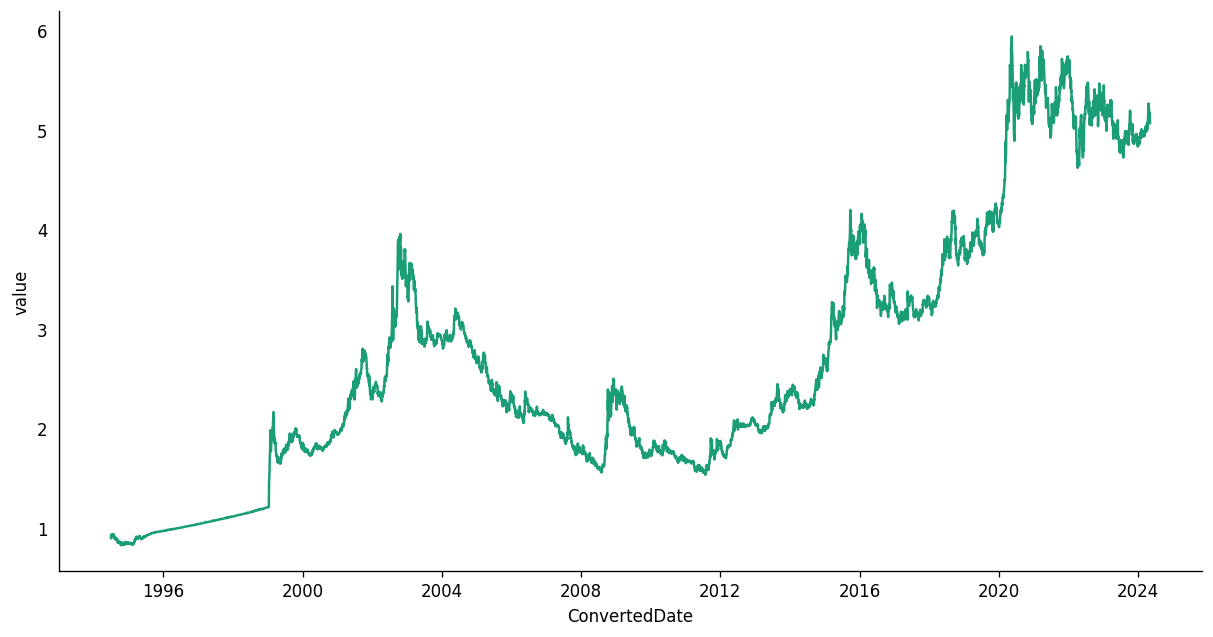

In [ ]:
# @title ConvertedDate vs value
# imprimindo o gráfico final
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['ConvertedDate']
  ys = series['value']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = usd.sort_values('ConvertedDate', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('ConvertedDate')
_ = plt.ylabel('value')
plt.show()

##References
1.	https://www.machinelearningplus.com/time-series/time-series-analysis-python/
2.	https://towardsdatascience.com/an-end-to-end-project-on-time-series-analysis-and-forecasting-with-python-4835e6bf050b
3.	https://towardsdatascience.com/time-series-analysis-in-python-an-introduction-70d5a5b1d52a
4.	https://www.digitalocean.com/community/tutorials/a-guide-to-time-series-visualization-with-python-3
5. https://www.kaggle.com/code/prashant111/complete-guide-on-time-series-analysis-in-python
1. [Time Series Forecasting Tutorial](https://www.datacamp.com/tutorial/tutorial-time-series-forecasting?utm_source=google&utm_medium=paid_search&utm_campaignid=19589720824&utm_adgroupid=157156375671&utm_device=m&utm_keyword=&utm_matchtype=&utm_network=g&utm_adpostion=&utm_creative=684592140413&utm_targetid=aud-517318242147:dsa-2218886984580&utm_loc_interest_ms=&utm_loc_physical_ms=9102164&utm_content=&utm_campaign=230119_1-sea~dsa~tofu_2-b2c_3-row-p2_4-prc_5-na_6-na_7-le_8-pdsh-go_9-na_10-na_11-na&gad_source=1&gclid=CjwKCAjwrcKxBhBMEiwAIVF8rJUDM6dKA9VpvU9MRxzlmqhySf-AHpm9-Z7Q8K8Ssz-EXIzZjP59cRoCNnMQAvD_BwE)
1. https://medium.com/analytics-vidhya/interpreting-acf-or-auto-correlation-plot-d12e9051cd14
1. https://www.escoladnc.com.br/blog/previsao-de-series-temporais-com-python-conceitos-modelos-e-aplicacoes/
